# Part 1 - Data Preparation

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from itertools import chain
import torch
import torch.nn as nn
import torchani

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [3]:
def init_aev_computer():
    Rcr = 5.2
    Rca = 3.5
    EtaR = torch.tensor([16], dtype=torch.float, device=device)
    ShfR = torch.tensor([
        0.900000, 1.168750, 1.437500, 1.706250, 
        1.975000, 2.243750, 2.512500, 2.781250, 
        3.050000, 3.318750, 3.587500, 3.856250, 
        4.125000, 4.393750, 4.662500, 4.931250
    ], dtype=torch.float, device=device)


    EtaA = torch.tensor([8], dtype=torch.float, device=device)
    Zeta = torch.tensor([32], dtype=torch.float, device=device)
    ShfA = torch.tensor([0.90, 1.55, 2.20, 2.85], dtype=torch.float, device=device)
    ShfZ = torch.tensor([
        0.19634954, 0.58904862, 0.9817477, 1.37444680, 
        1.76714590, 2.15984490, 2.5525440, 2.94524300
    ], dtype=torch.float, device=device)

    num_species = 4
    aev_computer = torchani.AEVComputer(
        Rcr, Rca, EtaR, ShfR, EtaA, Zeta, ShfA, ShfZ, num_species
    )
    return aev_computer

aev_computer = init_aev_computer()
aev_dim = aev_computer.aev_length
print(aev_dim)

384


In [4]:
def load_ani_dataset(dspath):
    self_energies = torch.tensor([
        0.500607632585, -37.8302333826,
        -54.5680045287, -75.0362229210
    ], dtype=torch.float, device=device)
    energy_shifter = torchani.utils.EnergyShifter(None)
    species_order = ['H', 'C', 'N', 'O']

    dataset = torchani.data.load(dspath)
    dataset = dataset.subtract_self_energies(energy_shifter, species_order)
    dataset = dataset.species_to_indices(species_order)
    dataset = dataset.shuffle()
    return dataset

dataset = load_ani_dataset("./ani_gdb_s01_to_s04.h5")
# Use dataset.split method to do split
# In the paper, 80% of the data is used for training, and 10% is used for each validation and testing.
train_data, test_data = dataset.split(0.9, 0.1) # This gives a 10% split for testing (and 90% for train + validation)

# Part 2 - Network Construction and Workflow Development

In [5]:
class ANITrainer:
    def __init__(self, model, batch_size, learning_rate, epoch, l2):
        self.model = model
        
        num_params = sum(item.numel() for item in model.parameters())
        print(f"{model.__class__.__name__} - Number of parameters: {num_params}")
        
        self.batch_size = batch_size
        self.optimizer = torch.optim.Adam(
                model.parameters(), learning_rate, weight_decay=l2
            )
        self.epoch = epoch
    
    def train(self, train_data, val_data, early_stop=True, draw_curve=True, fold=None):
        self.model.train()
        
        # init data loader
        print("Initialize training data...")
        train_data_loader = train_data.collate(self.batch_size).cache()
        
        # definition of loss function: MSE is a good choice! 
        loss_func = nn.MSELoss()
        
        # record epoch losses
        train_loss_list = []
        val_loss_list = []
        lowest_val_loss = np.inf
        
        for _ in tqdm(range(self.epoch), leave=True):
            train_epoch_loss = 0.0
            for train_data_batch in train_data_loader:
                
                # compute energies
                species = train_data_batch['species'].to(device)
                coords = train_data_batch['coordinates'].to(device)
                true_energies = train_data_batch['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(true_energies, pred_energies)
                
                # do a step
                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()
                
                batch_importance = species.shape[0] / len(train_data)
                train_epoch_loss += batch_loss.detach().cpu().item() * batch_importance
            
            # use the self.evaluate to get loss on the validation set 
            val_epoch_loss = self.evaluate(val_data, draw_plot=False)
            
            # append the losses
            train_loss_list.append(train_epoch_loss)
            val_loss_list.append(val_epoch_loss)
            
            if early_stop:
                if val_epoch_loss < lowest_val_loss:
                    lowest_val_loss = val_epoch_loss
                    weights = self.model.state_dict()
        
        if draw_curve:
            x_axis = np.arange(1, self.epoch + 1)
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.set_yscale("log")

            # Plot train loss and validation loss
            ax.plot(x_axis, train_loss_list, label='Train')
            ax.plot(x_axis, val_loss_list, label='Validation')
            ax.legend()
            ax.set_title(f"Training and Validation Loss for Fold {fold}")
            ax.set_xlabel("# Epoch")
            ax.set_ylabel("Loss")

            # Shows the train and validation loss for each fold 
            plt.show()
            plt.close(fig)
        
        if early_stop:
            self.model.load_state_dict(weights)
        
        return train_loss_list, val_loss_list
    
    
    def evaluate(self, data, draw_plot=False, get_mae=False, get_rmse=False, fold=None):
        
        # init data loader
        data_loader = data.collate(self.batch_size).cache()
        
        # init loss function
        loss_func = nn.MSELoss()
        total_loss = 0.0
        
        if draw_plot or get_mae or get_rmse:
            true_energies_all = []
            pred_energies_all = []
            
        with torch.no_grad():
            for batch_data in data_loader:
                
                # compute energies
                species = batch_data['species'].to(device)
                coords = batch_data['coordinates'].to(device)
                true_energies = batch_data['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(true_energies, pred_energies)

                batch_importance = species.shape[0] / len(data)
                total_loss += batch_loss.detach().cpu().item() * batch_importance
                
                if draw_plot or get_mae or get_rmse:
                    true_energies_all.append(true_energies.detach().cpu().numpy().flatten())
                    pred_energies_all.append(pred_energies.detach().cpu().numpy().flatten())

        if draw_plot:
            true_energies_all = np.concatenate(true_energies_all)
            pred_energies_all = np.concatenate(pred_energies_all)
            # Report the root mean squared error
            # The unit of energies in the dataset is hartree
            # please convert it to kcal/mol when reporting the mean absolute error
            # 1 hartree = 627.5094738898777 kcal/mol
            # MAE = mean(|true - pred|)
            hartree2kcalmol = 627.5094738898777
            # mae = np.mean(np.abs(true_energies_all * hartree2kcalmol - pred_energies_all * hartree2kcalmol)) 
            rmse = np.sqrt(np.mean((true_energies_all * hartree2kcalmol - pred_energies_all * hartree2kcalmol) ** 2))
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.scatter(true_energies_all, pred_energies_all, label=f"RMSE: {rmse:.2f} kcal/mol", s=2)
            ax.set_title(f"Predicted vs. True Energies for Fold {fold}")
            ax.set_xlabel("Ground Truth Energies (kcal/mol)")
            ax.set_ylabel("Predicted Energies (kcal/mol)")
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            vmin, vmax = min(xmin, ymin), max(xmax, ymax)
            ax.set_xlim(vmin, vmax)
            ax.set_ylim(vmin, vmax)
            ax.plot([vmin, vmax], [vmin, vmax], color='red')
            ax.legend()

            # Plots the loss for each set of data (train, val, test)
            plt.show()
            plt.close(fig)

        if get_mae:
            true_energies_all = np.concatenate(true_energies_all)
            pred_energies_all = np.concatenate(pred_energies_all)
            # Report the mean absolute error
            # The unit of energies in the dataset is hartree
            # please convert it to kcal/mol when reporting the mean absolute error
            # 1 hartree = 627.5094738898777 kcal/mol
            # MAE = mean(|true - pred|)
            hartree2kcalmol = 627.5094738898777
            mae = np.mean(np.abs(true_energies_all * hartree2kcalmol - pred_energies_all * hartree2kcalmol)) 
            return np.round(mae, 2)
        
        if get_rmse:
            true_energies_all = np.concatenate(true_energies_all)
            pred_energies_all = np.concatenate(pred_energies_all)
            # Report the root mean squared error
            # The unit of energies in the dataset is hartree
            # please convert it to kcal/mol when reporting the root mean squared error
            # 1 hartree = 627.5094738898777 kcal/mol
            # MSE = sqrt(mean((true - pred)^2))
            hartree2kcalmol = 627.5094738898777
            rmse = np.sqrt(np.mean((true_energies_all * hartree2kcalmol - pred_energies_all * hartree2kcalmol) ** 2))
            return np.round(rmse, 2)
            
        return total_loss
        

# Part 3 - Regularization Strategies and Hyperparameter Tuning

In [6]:
# These hyperparameters consistently yielded low MAE.
hidden_layers = 112
learning_rate = 1e-3
epoch = 100
l2 = 0

In [7]:
class AtomicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, hidden_layers),
            nn.ReLU(),
            nn.Linear(hidden_layers, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

## Part 4 - K-Fold Cross Validation

In [8]:
def KFoldCrossValidation(
    k, 
    all_train_data, test_data,
    early_break=False
):
    train_rmse_list, val_rmse_list, test_rmse_list = [], [], []
    best_fold, best_trainer, best_train_data, best_val_data, min_val_rmse = -1, None, None, None, float("inf")
    for i in np.arange(k):
        print(f"Fold {i}:")

        splits = all_train_data.split(*np.array([1/k] * k))
        train_parts = splits[:i] + splits[i+1:]
        train_wrapped_iterable = []
        for train_part in train_parts:
            train_wrapped_iterable += train_part.wrapped_iterable
        train_data = torchani.data.TransformableIterable(train_wrapped_iterable, all_train_data.transformations)
        val_data = splits[i]
        
        # Prepare a new ANI model in each fold
        net_H = AtomicNet()
        net_C = AtomicNet()
        net_N = AtomicNet()
        net_O = AtomicNet()

        # ANI model requires a network for each atom type
        # use torch.ANIModel() to compile atomic networks
        ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
        model = nn.Sequential(
            aev_computer,
            ani_net
        ).to(device)
        
        trainer = ANITrainer(
            model,
            batch_size=1024,
            learning_rate=learning_rate,
            epoch=epoch,
            l2=l2
        )
        
        train_losses, val_losses = trainer.train(train_data, val_data, fold=i)
        train_rmse = trainer.evaluate(train_data, get_rmse=True)
        val_rmse = trainer.evaluate(val_data, get_rmse=True)
        test_rmse = trainer.evaluate(test_data, get_rmse=True)
        
        train_rmse_list.append(train_rmse)
        val_rmse_list.append(val_rmse)
        test_rmse_list.append(test_rmse)
        
        print(f"Training RMSE: {train_rmse:.2f}")
        print(f"Validation RMSE: {val_rmse:.2f}")
        print(f"Test RMSE: {test_rmse:.2f}")
        print("------------------")

        # Store best val RMSE trainer and model
        if val_rmse < min_val_rmse:
            best_fold = i
            min_val_rmse = val_rmse
            best_trainer = trainer
            best_train_data = train_data
            best_val_data = val_data
        
        if early_break:
            break
    
    if not early_break:
        print("Final results:")
        print(f"Training RMSE: {np.mean(train_rmse_list):.2f}+/-{np.std(train_rmse_list):.3f}")
        print(f"Validation RMSE: {np.mean(val_rmse_list):.2f}+/-{np.std(val_rmse_list):.3f}")
        print(f"Test RMSE: {np.mean(test_rmse_list):.2f}+/-{np.std(test_rmse_list):.3f}")

        print("------------------")
        print("Compared to results from the ANI paper:")
        print("Training RMSE: 1.2")
        print("Validation RMSE: 1.3")
        print("Test RMSE: 1.3")

        print("------------------")
        print(f"Predicted vs. True Energies for Best Fold: Fold {best_fold}")
        best_trainer.evaluate(best_train_data, draw_plot=True, fold=best_fold)
        best_trainer.evaluate(best_val_data, draw_plot=True, fold=best_fold)
        best_trainer.evaluate(test_data, draw_plot=True, fold=best_fold)

Fold 0:
Sequential - Number of parameters: 172932
Initialize training data...


100%|██████████| 100/100 [17:32<00:00, 10.53s/it]


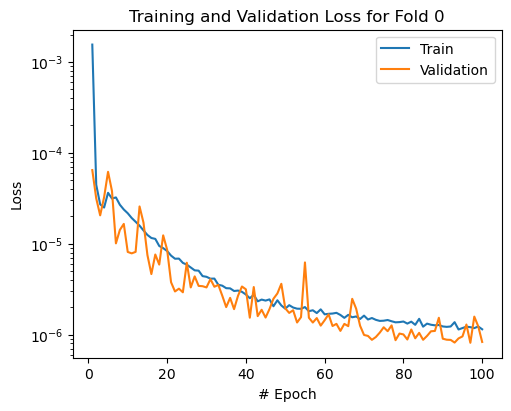

Training RMSE: 0.55
Validation RMSE: 0.57
Test RMSE: 0.57
------------------
Fold 1:
Sequential - Number of parameters: 172932
Initialize training data...


100%|██████████| 100/100 [15:58<00:00,  9.58s/it]


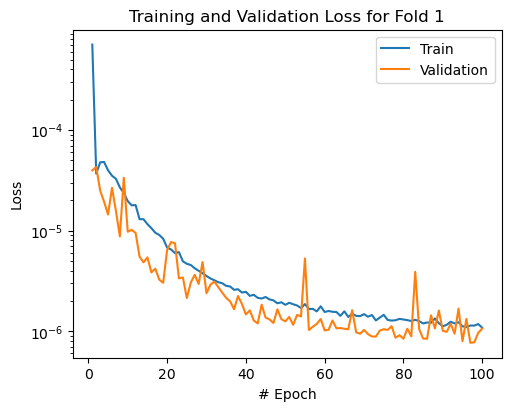

Training RMSE: 0.60
Validation RMSE: 0.65
Test RMSE: 0.63
------------------
Fold 2:
Sequential - Number of parameters: 172932
Initialize training data...


100%|██████████| 100/100 [15:53<00:00,  9.54s/it]


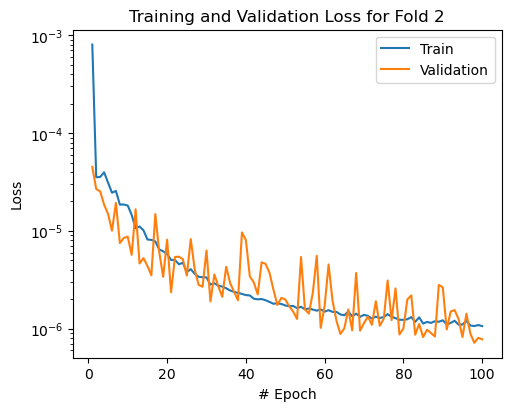

Training RMSE: 0.51
Validation RMSE: 0.55
Test RMSE: 0.54
------------------
Fold 3:
Sequential - Number of parameters: 172932
Initialize training data...


100%|██████████| 100/100 [17:53<00:00, 10.73s/it]


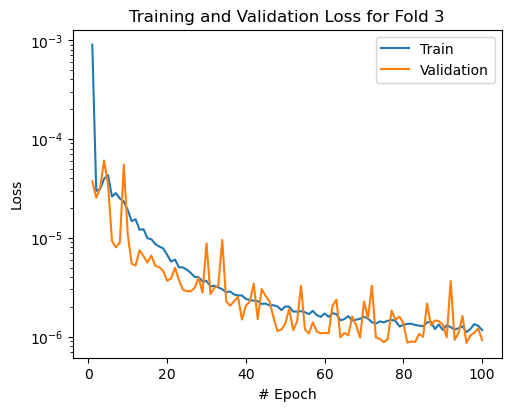

Training RMSE: 0.57
Validation RMSE: 0.60
Test RMSE: 0.59
------------------
Fold 4:
Sequential - Number of parameters: 172932
Initialize training data...


100%|██████████| 100/100 [15:13<00:00,  9.13s/it]


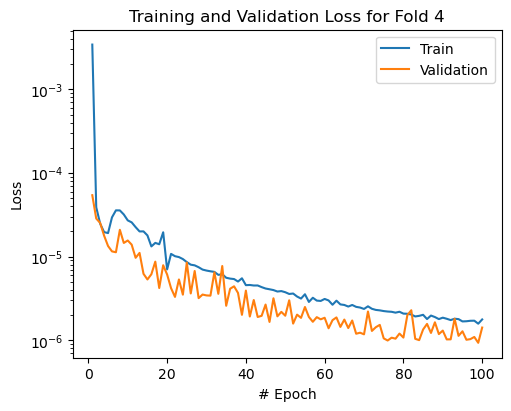

Training RMSE: 0.71
Validation RMSE: 0.75
Test RMSE: 0.73
------------------
Fold 5:
Sequential - Number of parameters: 172932
Initialize training data...


100%|██████████| 100/100 [15:17<00:00,  9.17s/it]


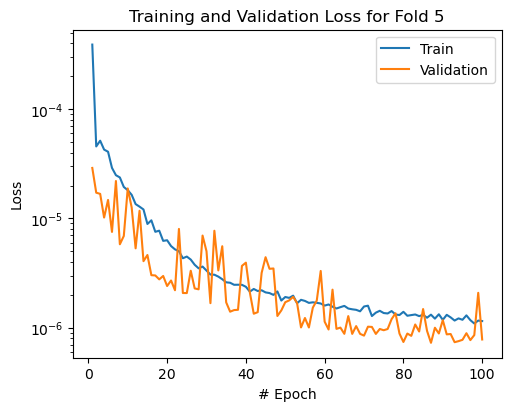

Training RMSE: 0.53
Validation RMSE: 0.56
Test RMSE: 0.55
------------------
Fold 6:
Sequential - Number of parameters: 172932
Initialize training data...


100%|██████████| 100/100 [14:53<00:00,  8.94s/it]


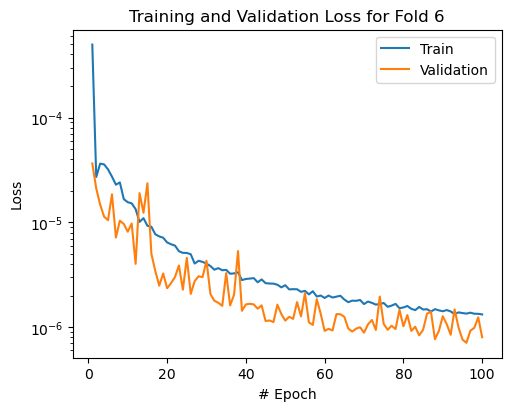

Training RMSE: 0.54
Validation RMSE: 0.56
Test RMSE: 0.56
------------------
Fold 7:
Sequential - Number of parameters: 172932
Initialize training data...


100%|██████████| 100/100 [14:26<00:00,  8.66s/it]


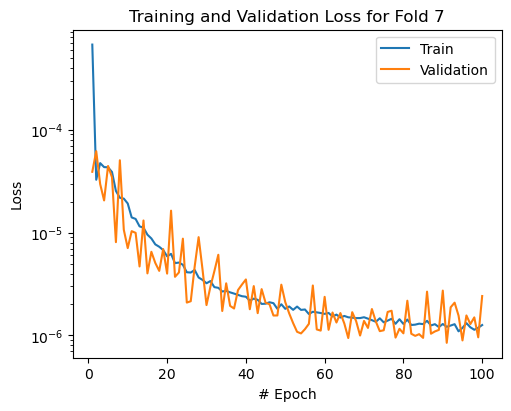

Training RMSE: 0.95
Validation RMSE: 0.98
Test RMSE: 0.96
------------------
Fold 8:
Sequential - Number of parameters: 172932
Initialize training data...


100%|██████████| 100/100 [14:23<00:00,  8.63s/it]


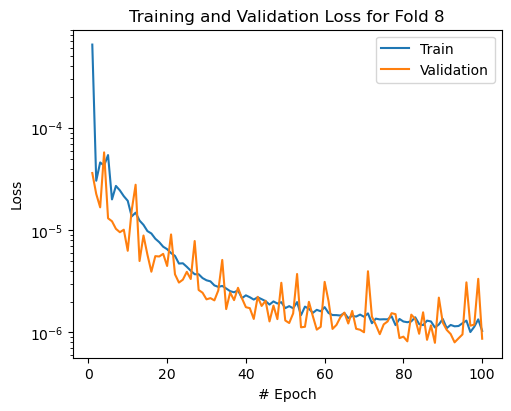

Training RMSE: 0.55
Validation RMSE: 0.58
Test RMSE: 0.57
------------------
Final results:
Training RMSE: 0.61+/-0.132
Validation RMSE: 0.64+/-0.133
Test RMSE: 0.63+/-0.128
------------------
Compared to results from the ANI paper:
Training RMSE: 1.2
Validation RMSE: 1.3
Test RMSE: 1.3
------------------
Predicted vs. True Energies for Best Fold: Fold 2


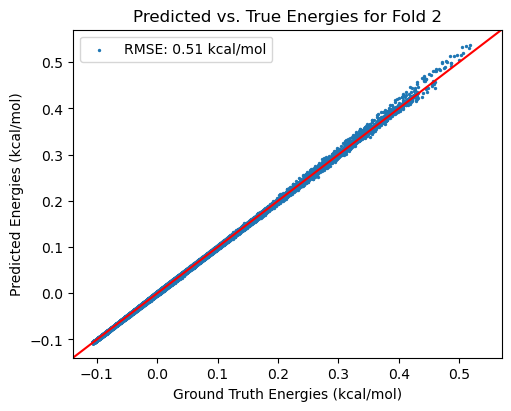

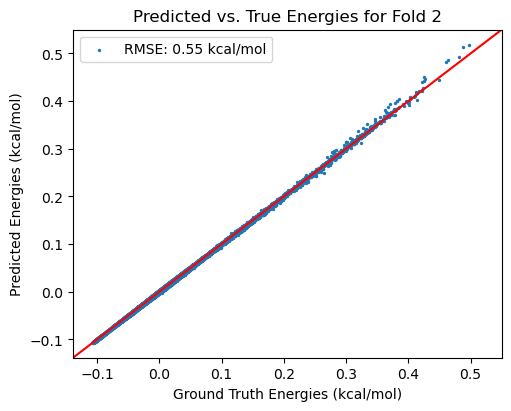

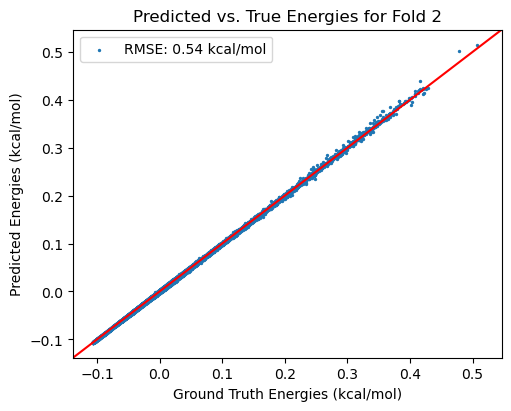

In [9]:
# 9 folds on 90% of the original data gives 80% training and 10% validation, relative to original dataset
KFoldCrossValidation(9, train_data, test_data)

In [10]:
print("Done") # This cell is here so that the above saves

Done
